<a href="https://colab.research.google.com/github/Memucan-ctrl/codveda-ml-internship/blob/main/level3_task1_random_forest/random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Level 3 — Task 1: Random Forest Classifier

Dataset: Wine (sklearn)
Model: RandomForestClassifier tuned via GridSearchCV
Results: Accuracy = 1.00, CV f1_macro = 0.986
Best params: max_depth=None, n_estimators=100
Top features: color_intensity, flavanoids, proline

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
CV f1_macro: 0.9863203463203462
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



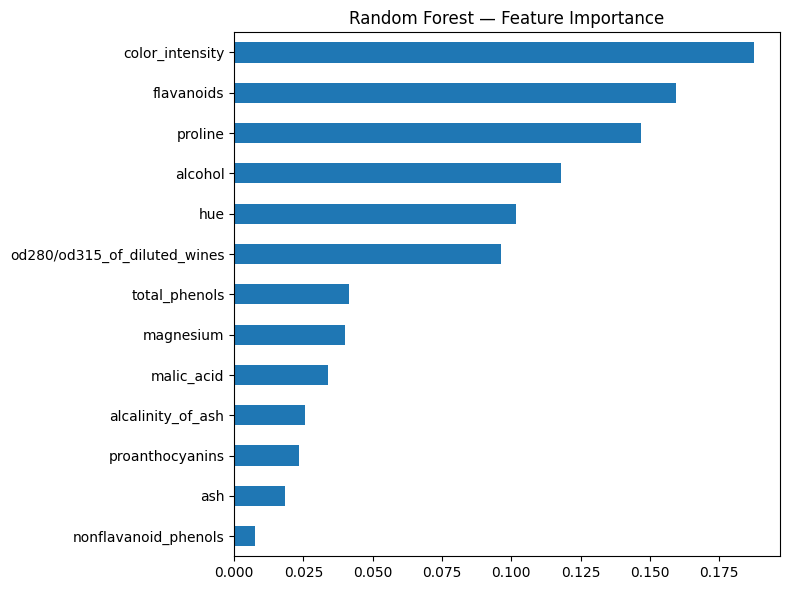

In [2]:
import pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X, y = load_wine(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth':    [None, 5, 10, 20],
    'min_samples_split': [2, 5],
}
gs = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                  param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
gs.fit(X_train, y_train)
best = gs.best_estimator_
print('Best params:', gs.best_params_)
print('CV f1_macro:', cross_val_score(best, X_train, y_train, cv=5, scoring='f1_macro').mean())
print(classification_report(y_test, best.predict(X_test)))

# Feature importance
imp = pd.Series(best.feature_importances_, index=X.columns).sort_values()
imp.plot.barh(figsize=(8,6))
plt.title('Random Forest — Feature Importance')
plt.tight_layout(); plt.show()